In [1]:
# pip install ydata-profiling
from ydata_profiling import ProfileReport
import pandas as pd
df = pd.read_csv("winequality-red.csv")

# Generate the data profiling report, title is just 
# report = ProfileReport(df, title='Red wine classification dataset, Advanced Data Analytics -course')

# create either an HTML -page or show it straight in the notebook
# sometimes the HTML -page is easier to browse!
# report.to_file("ydata_redwine_data_report.html")

In [2]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [3]:
df.corr()['quality'].sort_values(ascending=False)

quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64

In [4]:
import phik
# compute phik-matrix values
phik_matrix = df.phik_matrix()

phik_matrix['quality'].sort_values(ascending=False)

interval columns not set, guessing: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


quality                 1.000000
alcohol                 0.446570
volatile acidity        0.439844
sulphates               0.331899
citric acid             0.295440
chlorides               0.254780
density                 0.240927
total sulfur dioxide    0.224657
fixed acidity           0.189783
residual sugar          0.142188
pH                      0.134442
free sulfur dioxide     0.080553
Name: quality, dtype: float64

In [5]:
# can process the whole dataset 
# and compares variables to each other instead
# of focusing on outliers on a single variable
from sklearn.ensemble import IsolationForest
import pandas as pd
df = pd.read_csv("winequality-red.csv")
# adjust the contamination rate as you see fit
# for example, if you expect 5% of the data to be outliers
# you can use 0.05 etc. 

# basically, this is how aggressive Isolation Forest will be
# increase if you think you need to detect more outliers
# decrease if you need less outliers
iso = IsolationForest(contamination=0.05) 


# REMEMBER! Isolation Forest is a machine learning algorithm
# => ALL VARIABLES HAVE TO BE NUMERIC AT THIS POINT

# fit isolation forest
y_pred = iso.fit_predict(df)

# separate outliers and inliers into separate DataFrames
outliers = df[y_pred != 1]
inliers = df[y_pred == 1]

print(f"Inliers: {len(inliers)}")
print(f"Outliers: {len(outliers)}")

Inliers: 1519
Outliers: 80


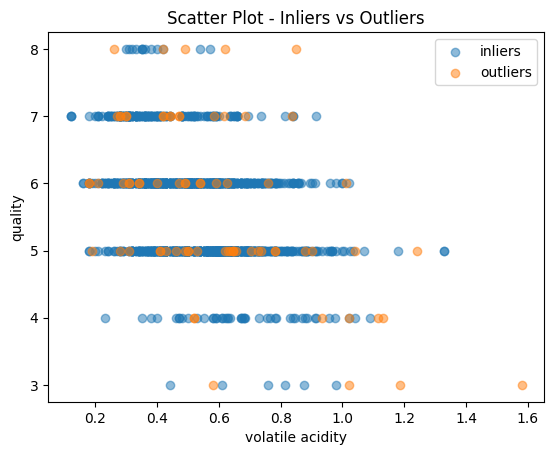

In [7]:
import matplotlib.pyplot as plt

# change the variable if you want to inspect this from other point of views
variable = "volatile acidity"
target = "quality"

# if you want to reduce the number of points visualized
# sample a small amount of points, for example 300-500
inliers_sample = inliers.sample(1500)
outliers_sample = outliers.sample(75)

plt.scatter(inliers_sample[variable], inliers_sample[target], label="inliers", alpha=0.5)
plt.scatter(outliers_sample[variable], outliers_sample[target], label="outliers", alpha=0.5)

plt.xlabel(variable)
plt.ylabel(target)

plt.title("Scatter Plot - Inliers vs Outliers")
plt.legend()
plt.show()

In [9]:
import numpy as np
import pandas as pd

variable = "quality"

# Calculate the median
median = df[variable].median()

# Calculate MAD
mad = np.median(np.abs(df[variable] - median))

# Define a threshold for noise detection
# adjust the numeric modifier for aggressiveness 
# e.g. try 2.5 or 4.5 etc.
# if the value is too high, you will find no noise (decrease in that case)
threshold = 2.5 * mad

# Detect noise
noise = df[np.abs(df[variable] - median) > threshold]

inliers = df.drop(noise.index)

print("Detected noise using MAD:")
noise

Detected noise using MAD:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
459,11.6,0.580,0.66,2.20,0.074,10.0,47.0,1.00080,3.25,0.57,9.00,3
517,10.4,0.610,0.49,2.10,0.200,5.0,16.0,0.99940,3.16,0.63,8.40,3
690,7.4,1.185,0.00,4.25,0.097,5.0,14.0,0.99660,3.63,0.54,10.70,3
832,10.4,0.440,0.42,1.50,0.145,34.0,48.0,0.99832,3.38,0.86,9.90,3
899,8.3,1.020,0.02,3.40,0.084,6.0,11.0,0.99892,3.48,0.49,11.00,3
1299,7.6,1.580,0.00,2.10,0.137,5.0,9.0,0.99476,3.50,0.40,10.90,3
1374,6.8,0.815,0.00,1.20,0.267,16.0,29.0,0.99471,3.32,0.51,9.80,3
1469,7.3,0.980,0.05,2.10,0.061,20.0,49.0,0.99705,3.31,0.55,9.70,3
1478,7.1,0.875,0.05,5.70,0.082,3.0,14.0,0.99808,3.40,0.52,10.20,3
1505,6.7,0.760,0.02,1.80,0.078,6.0,12.0,0.99600,3.55,0.63,9.95,3


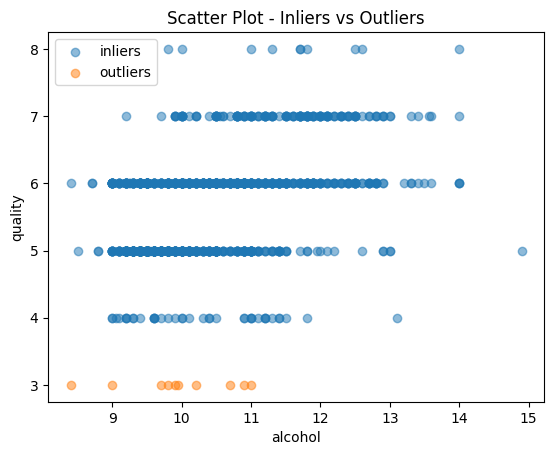

In [11]:
import matplotlib.pyplot as plt

# change the variable if you want to inspect this from other point of views
variable = "alcohol"
target = "quality"

# if you want to reduce the number of points visualized
# sample a small amount of points, for example 300-500
inliers_sample = inliers.sample(1200)
outliers_sample = noise.sample(10)

plt.scatter(inliers_sample[variable], inliers_sample[target], label="inliers", alpha=0.5)
plt.scatter(outliers_sample[variable], outliers_sample[target], label="outliers", alpha=0.5)

plt.xlabel(variable)
plt.ylabel(target)

plt.title("Scatter Plot - Inliers vs Outliers")
plt.legend()
plt.show()

In [12]:
# perform X/y -split
# if you  have more than one independent variable, list them all here
# leave out the target variable! (dependent variable)

# this is a nice and common trick => everything EXCEPT target variable => support variable
X = df.drop("quality", axis=1)

# have only the target variable here (dependent variable)
y = df["quality"]

In [13]:
# pip install statsmodels
from statsmodels.stats.outliers_influence import variance_inflation_factor 

# VIF dataframe 
# VIF = Variance Inflation Factor
vif_data = pd.DataFrame() 
vif_data["feature"] = X.columns 
  
# calculating VIF for each feature 
vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                          for i in range(len(X.columns))] 
  

# variables with high VIF-value 
# can mean multlicollinearity (variables providing same linear
# relationships in the data, potentially confusing the ML algorithm
# this might be good info when deciding if some variable needs to be removed
vif_data

,feature,VIF
0,fixed acidity,74.452265
1,volatile acidity,17.060026
2,citric acid,9.183495
3,residual sugar,4.662992
4,chlorides,6.554877
5,free sulfur dioxide,6.442682
6,total sulfur dioxide,6.519699
7,density,1479.287209
8,pH,1070.967685
9,sulphates,21.590621


In [14]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

# convert all continuous variables to integer,
# and convert all negative numbers to 0
X_cat = X.astype(int)
X_cat = X_cat.clip(lower=0)

# initialize chi2 and SelectKBest
# Note: chi2 -test is a very common test
# in statistics and quantitative analysis
# basically it studies the data whether variables are related
# or independent of each other
chi_2_features = SelectKBest(chi2, k=len(X_cat.columns))

# fit our data to the SelectKBest
best_features = chi_2_features.fit(X_cat,y.astype(int))

# use decimal format in table print later
pd.options.display.float_format = '{:.2f}'.format

# wrap it up, and show the results
# the higher the score, the more effect that column has on price
df_features = pd.DataFrame(best_features.scores_)
df_columns = pd.DataFrame(X_cat.columns)
f_scores = pd.concat([df_columns,df_features],axis=1)
f_scores.columns = ['Features','Score']
f_scores.sort_values(by='Score',ascending=False)

,Features,Score
6,total sulfur dioxide,2755.16
5,free sulfur dioxide,162.20
1,volatile acidity,93.61
10,alcohol,47.61
2,citric acid,29.17
0,fixed acidity,11.55
3,residual sugar,6.00
9,sulphates,5.36
7,density,1.66
8,pH,0.06


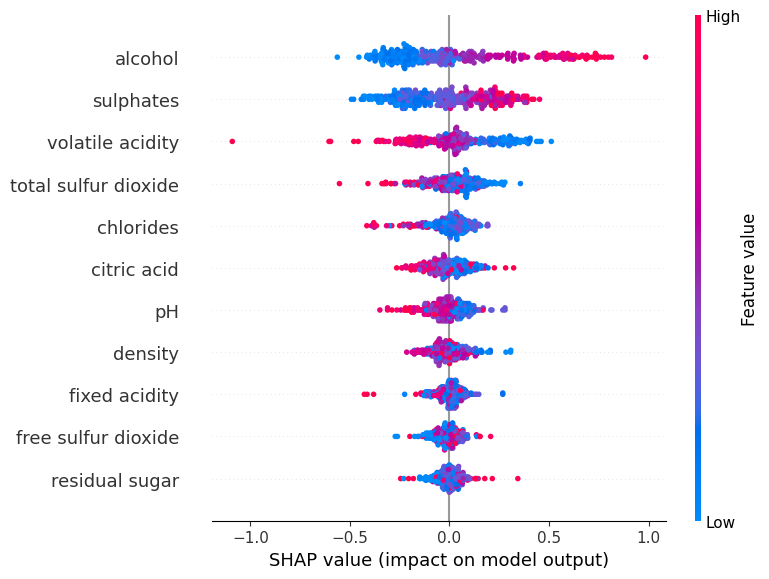

Feature Importances using SHAP:
                 Feature  Importance
0          fixed acidity        0.05
1       volatile acidity        0.16
2            citric acid        0.07
3         residual sugar        0.04
4              chlorides        0.07
5    free sulfur dioxide        0.04
6   total sulfur dioxide        0.09
7                density        0.06
8                     pH        0.07
9              sulphates        0.18
10               alcohol        0.26


In [15]:
import shap
import xgboost as xgb
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np


# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# use GPU-enabled XGBoost Regressor
model = xgb.XGBRegressor(tree_method='gpu_hist')
model.fit(X_train, y_train)

# Initialize SHAP explainer
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# Plot SHAP summary
shap.summary_plot(shap_values, X_test)

# Feature importance using SHAP values
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': np.mean(np.abs(shap_values.values), axis=0)  # shap_values.values for the matrix
})

print("Feature Importances using SHAP:")
print(importance)
